# End-to-End-Sales Analysis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Importing And Cleaning

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file_path = "/content/drive/MyDrive/orders.csv"
order = pd.read_csv(file_path)

In [5]:
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 8:38:49,2018-08-08 8:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 0:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 0:28:42,2017-12-15 0:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 0:00:00


In [6]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
order.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [8]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])

In [9]:
file_path = "/content/drive/MyDrive/products.csv"
product = pd.read_csv(file_path)
product.head()

,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sport leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,babies,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product category            32341 non-null  object 
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [11]:
product['product category'] = product['product category'].fillna('Unknown')

In [12]:
file_path = "/content/drive/MyDrive/customers.csv"
customer = pd.read_csv(file_path)
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [13]:
customer.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [14]:
file_path = "/content/drive/MyDrive/order_items.csv"
order_item = pd.read_csv(file_path)
order_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 9:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [15]:
order_item.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [16]:
file_path = "/content/drive/MyDrive/sellers.csv"
seller = pd.read_csv(file_path)
seller.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [17]:
seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [18]:
file_path = "/content/drive/MyDrive/payments.csv"
payment = pd.read_csv(file_path)
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [19]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


# Exploratory Data Analysis

['franca' 'sao bernardo do campo' 'sao paulo' ... 'monte bonito'
 'sao rafael' 'eugenio de castro']


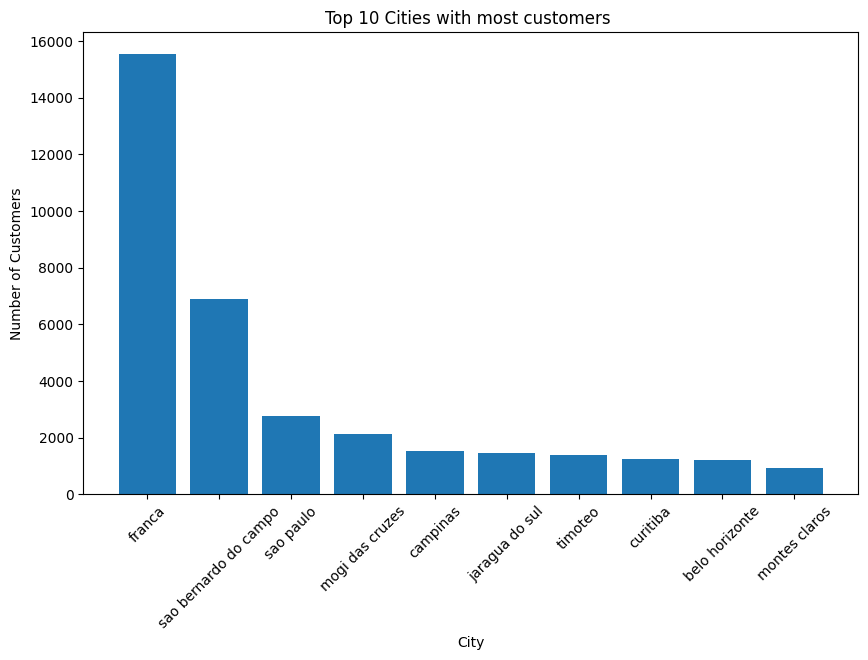

In [20]:
# all unique cities where customers are located
unique_cities = customer['customer_city'].unique()
print(unique_cities)
plt.figure(figsize=(10, 6))
plt.bar(unique_cities[:10], customer['customer_city'].value_counts()[:10])
plt.title('Top 10 Cities with most customers ')
plt.ylabel('Number of Customers')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.show()

In [21]:
# number of orders placed in 2017
order_2017= order[order['order_purchase_timestamp'].dt.year == 2017]
print("Total order placed in 2017:" , len(order_2017))

Total order placed in 2017: 45101


In [22]:
#Total sales per category
category_data = pd.merge(order_item, product, on='product_id')
total_sales = category_data.groupby('product category')['price'].sum().sort_values(ascending=True).tail(10)
print(total_sales)

product category
Garden tools             485256.46
automotive               592720.11
housewares               632248.66
Cool Stuff               635290.85
Furniture Decoration     729762.49
computer accessories     911954.32
sport leisure            988048.97
bed table bath          1036988.68
Watches present         1205005.68
HEALTH BEAUTY           1258681.34
Name: price, dtype: float64


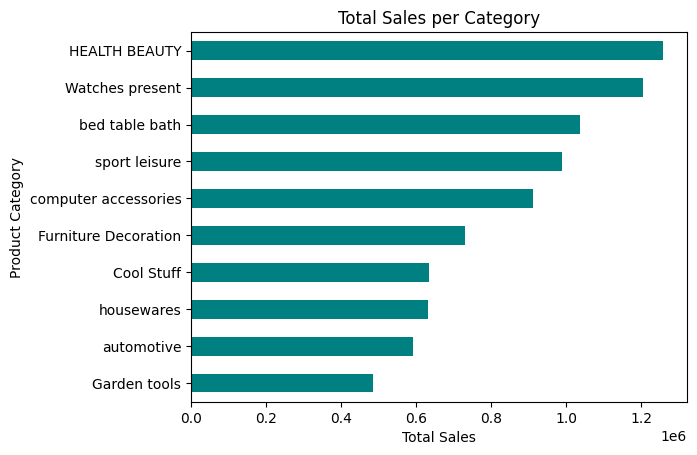

In [23]:
total_sales.plot(kind='barh', color='teal')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.title('Total Sales per Category')
plt.show()

In [24]:
# percentage of orders that were paid in installments
Total_order = payment['order_id'].nunique()
Installment_order = payment[payment['payment_installments'] > 1]['order_id'].nunique()
Installment_percentage = Total_order / Installment_order * 100
print(f"percentage of orders paid in installments: {Installment_percentage:.2f}%")


percentage of orders paid in installments: 194.33%


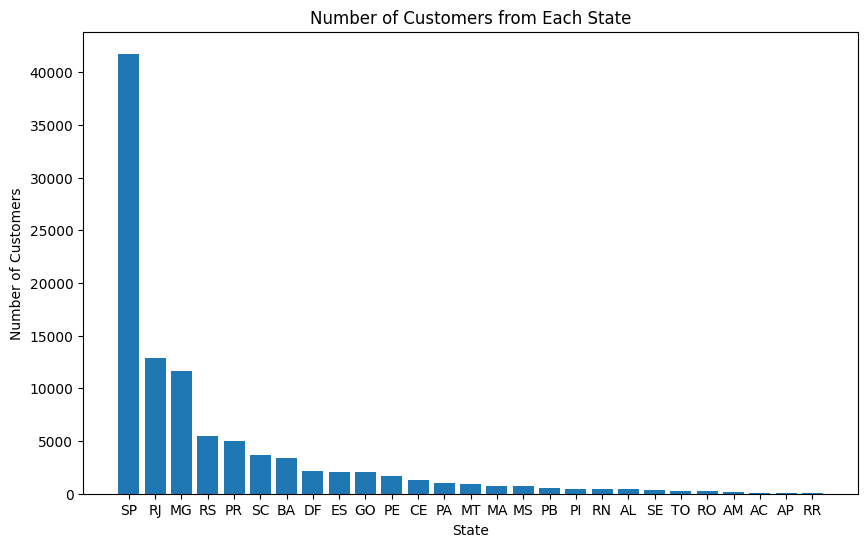

In [25]:
# number of customers from each state
customer_state = customer['customer_state'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(customer_state.index ,customer_state.values)
plt.title('Number of Customers from Each State')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

order_purchase_timestamp
Jan    7269
Feb    6728
Mar    7211
Apr    6939
May    6873
Jun    6167
Jul    6292
Aug    6512
Sep      16
Oct       4
Name: count, dtype: int64


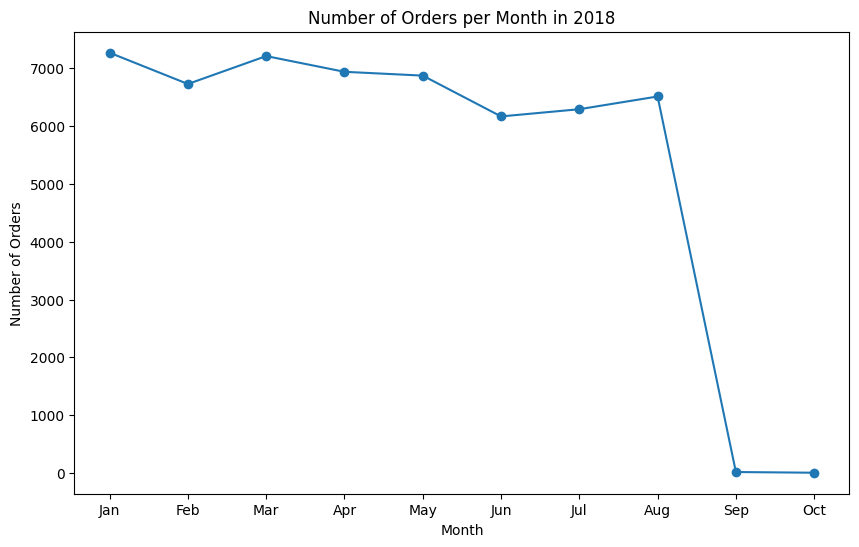

In [26]:
# Calculate the number of orders per month in 2018.
orders_2018 =order[order['order_purchase_timestamp'].dt.year== 2018].copy()
month_name = orders_2018['order_purchase_timestamp'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar','Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep','Oct']
monthly_count = month_name.value_counts().reindex(month_order)
print(monthly_count)
plt.figure(figsize=(10, 6))
plt.plot(monthly_count.index , monthly_count.values , marker ='o')
plt.title('Number of Orders per Month in 2018')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

In [27]:
# average number of products per order, grouped by customer city
orders = order_item.merge(order , on = 'order_id').merge(customer, on='customer_id')
city_avg = orders.groupby('customer_city')['order_item_id'].max().groupby('customer_city').mean()
print(city_avg.sort_values(ascending= False).head(10))


customer_city
sao paulo                21.0
goiania                  20.0
uniao da vitoria         15.0
indaiatuba               14.0
santos                   14.0
belo horizonte           12.0
curitiba                 12.0
celso ramos              12.0
juiz de fora             12.0
alto paraiso de goias    11.0
Name: order_item_id, dtype: float64


product category
HEALTH BEAUTY           9.260700
Watches present         8.865783
bed table bath          7.629605
sport leisure           7.269533
computer accessories    6.709669
Furniture Decoration    5.369200
Cool Stuff              4.674128
housewares              4.651745
automotive              4.360916
Garden tools            3.570256
Name: price, dtype: float64


Text(0.5, 1.0, 'Percentage of Total Revenue by Product Category')

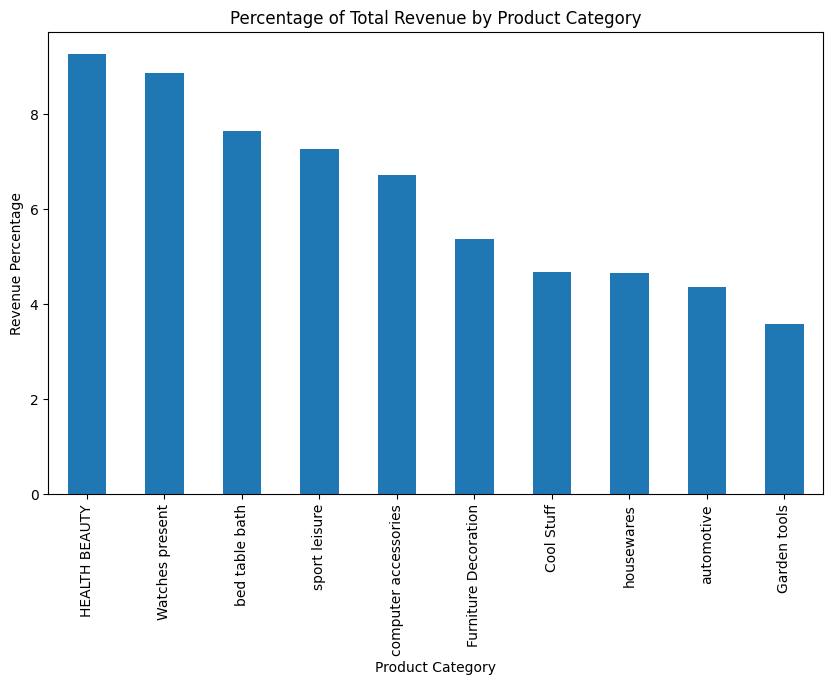

In [28]:
#percentage of total revenue contributed by each product category.
merge_table = pd.merge(order_item, product, on = 'product_id')
total_revenue = merge_table.groupby('product category')['price'].sum()
revenue_percentage = (total_revenue / total_revenue.sum()*100).sort_values(ascending=False ).head(10)
print(revenue_percentage)
revenue_percentage.plot(kind = 'bar' , figsize= (10,6))
plt.xlabel('Product Category')
plt.ylabel('Revenue Percentage')
plt.title('Percentage of Total Revenue by Product Category')


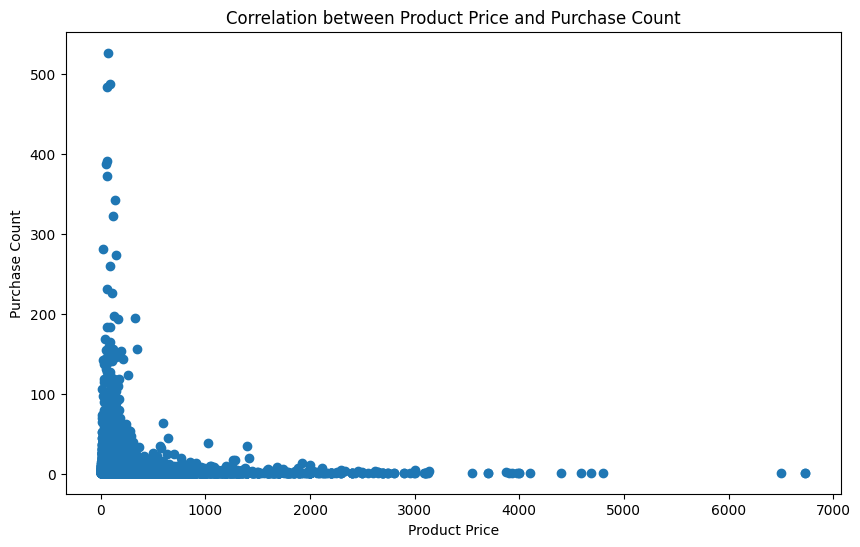

In [29]:
# correlation between product price and the number of times a product has been purchased
correlation_data = order_item.groupby('product_id').agg({'price': 'mean', 'order_item_id': 'count'})
correlation_data.columns = ['product_price', 'purchase_count']
plt.figure(figsize=(10, 6))
plt.scatter(correlation_data['product_price'], correlation_data['purchase_count'])
plt.title('Correlation between Product Price and Purchase Count')
plt.xlabel('Product Price')
plt.ylabel('Purchase Count')
plt.show()


                             seller_id      price  seller_rank
857   4869f7a5dfa277a7dca6462dcf3b52b2  229472.63            1
1013  53243585a1d6dc2643021fd1853d8905  222776.05            2
881   4a3ca9315b744ce9f8e9374361493884  200472.92            3
3024  fa1c13f2614d7b5c4749cbc52fecda94  194042.03            4
1535  7c67e1448b00f6e969d365cea6b010ab  187923.89            5
1560  7e93a43ef30c4f03f38b393420bc753a  176431.87            6
2643  da8622b14eb17ae2831f4ac5b9dab84a  160236.57            7
1505  7a67c85e85bb2ce8582c35f2203ad736  141745.53            8
192   1025f0e2d44d7041d6cf58b6550e0bfa  138968.55            9
1824  955fee9216a65b617aa5c0531780ce60  135171.70           10


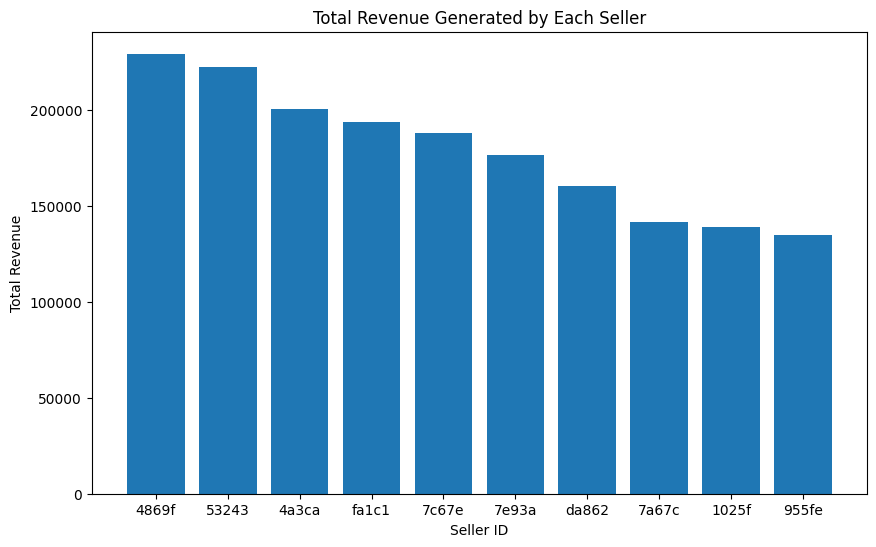

In [30]:
# Calculate the total revenue generated by each seller, and rank them by revenue.
seller_revenue = order_item.groupby('seller_id')['price'].sum().reset_index()
seller_revenue['seller_rank']= seller_revenue['price'].rank(ascending=False).astype(int)
Top_selllers = seller_revenue.sort_values(by='seller_rank').head(10)
print(Top_selllers)
plt.figure(figsize=(10, 6))
plt.bar(Top_selllers['seller_id'].str[:5], Top_selllers['price'])
plt.title('Total Revenue Generated by Each Seller')
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue')
plt.show()


In [31]:
# Calculate the moving average of order values for each customer over their order history

merge = order_item.merge(order[['order_id', 'customer_id', 'order_purchase_timestamp']], on='order_id').merge(customer[['customer_id', 'customer_unique_id']], on='customer_id')
merge = merge.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

merge['moving_avg'] = merge.groupby('customer_unique_id')['price'].transform(lambda x: x.expanding().mean())
print(merge[['customer_unique_id', 'order_purchase_timestamp', 'price', 'moving_avg']].head(10))

                     customer_unique_id order_purchase_timestamp   price  \
99743  0000366f3b9a7992bf8c76cfdf3221e2      2018-05-10 10:56:27  129.90   
23496  0000b849f77a49e4a4ce2b2a4ca5be3f      2018-05-07 11:11:27   18.90   
78796  0000f46a3911fa3c0805444483337064      2017-03-10 21:05:03   69.00   
28613  0000f6ccb0745a6a4b88665a16c9f078      2017-10-12 20:29:41   25.99   
95800  0004aac84e0df4da2b147fca70cf8255      2017-11-14 19:45:42  180.00   
27375  0004bd2a26a76fe21f786e4fbd80607f      2018-04-05 19:33:16  154.00   
91676  00050ab1314c0e55a6ca13cf7181fecf      2018-04-20 12:57:23   27.99   
30347  00053a61a98854899e70ed204dd4bafe      2018-02-28 11:15:41  191.00   
30348  00053a61a98854899e70ed204dd4bafe      2018-02-28 11:15:41  191.00   
76624  0005e1862207bf6ccc02e4228effd9a0      2017-03-04 23:32:12  135.00   

       moving_avg  
99743      129.90  
23496       18.90  
78796       69.00  
28613       25.99  
95800      180.00  
27375      154.00  
91676       27.99  
303

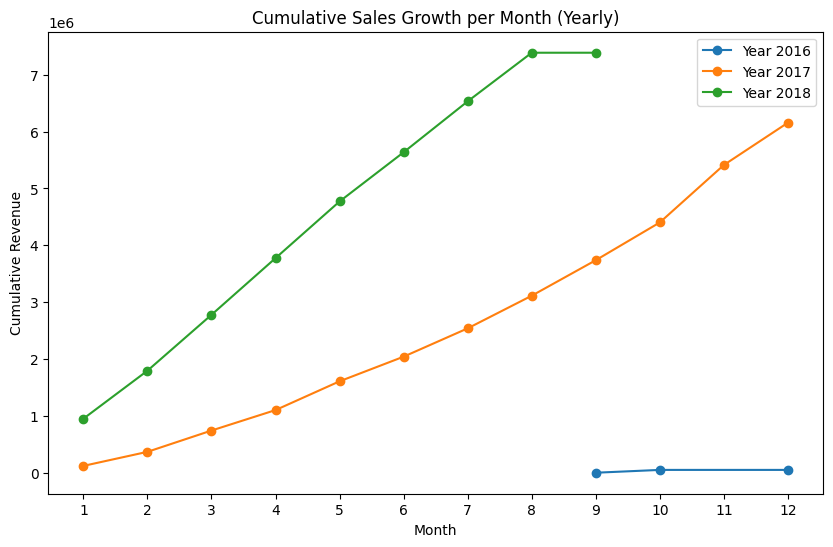

In [32]:
# Calculate the cumulative sales per month for each year
sales_df = pd.merge(order_item[['order_id', 'price']], order[['order_id', 'order_purchase_timestamp']], on='order_id')
sales_df['year'] = sales_df['order_purchase_timestamp'].dt.year
sales_df['month'] = sales_df['order_purchase_timestamp'].dt.month

monthly_sum = sales_df.groupby(['year', 'month'])['price'].sum().reset_index()
monthly_sum['cum_sales'] = monthly_sum.groupby('year')['price'].cumsum()

plt.figure(figsize=(10, 6))
for year in monthly_sum['year'].unique():
    year_data = monthly_sum[monthly_sum['year'] == year]
    plt.plot(year_data['month'], year_data['cum_sales'], marker='o', label=f'Year {year}')

plt.title('Cumulative Sales Growth per Month (Yearly)')
plt.xlabel('Month')
plt.ylabel('Cumulative Revenue')
plt.xticks(range(1, 13))
plt.legend()
plt.show()

Yearly Sales and Growth Rate:
   year       price    yoy_growth
0  2016    49785.92           NaN
1  2017  6155806.98  12264.554035
2  2018  7386050.80     19.985094


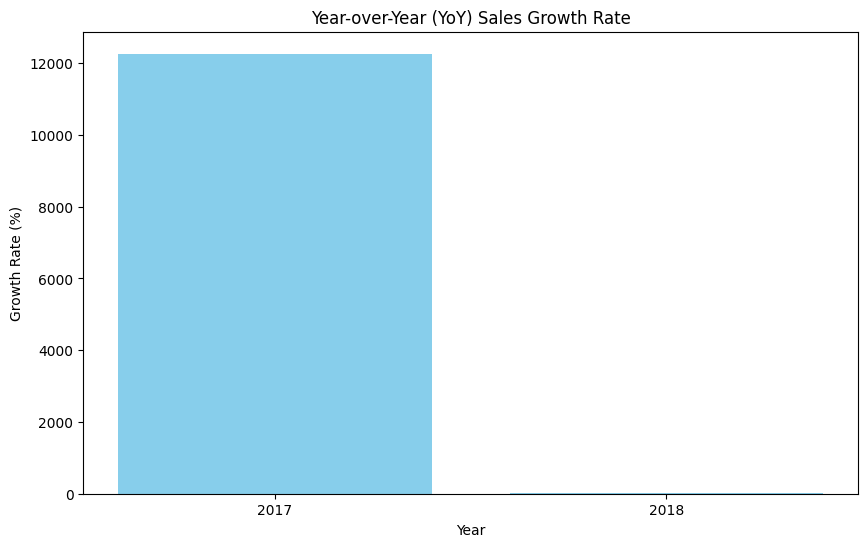

In [33]:
# Calculate the year-over-year growth rate of total sales.
yearly_sales = sales_df.groupby('year')['price'].sum().reset_index()
yearly_sales['yoy_growth'] = yearly_sales['price'].pct_change() * 100
print("Yearly Sales and Growth Rate:")
print(yearly_sales)

plt.figure(figsize=(10, 6))
plt.bar(yearly_sales['year'].astype(str), yearly_sales['yoy_growth'], color='skyblue')
plt.title('Year-over-Year (YoY) Sales Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.show()

Retentation rate:3.05%


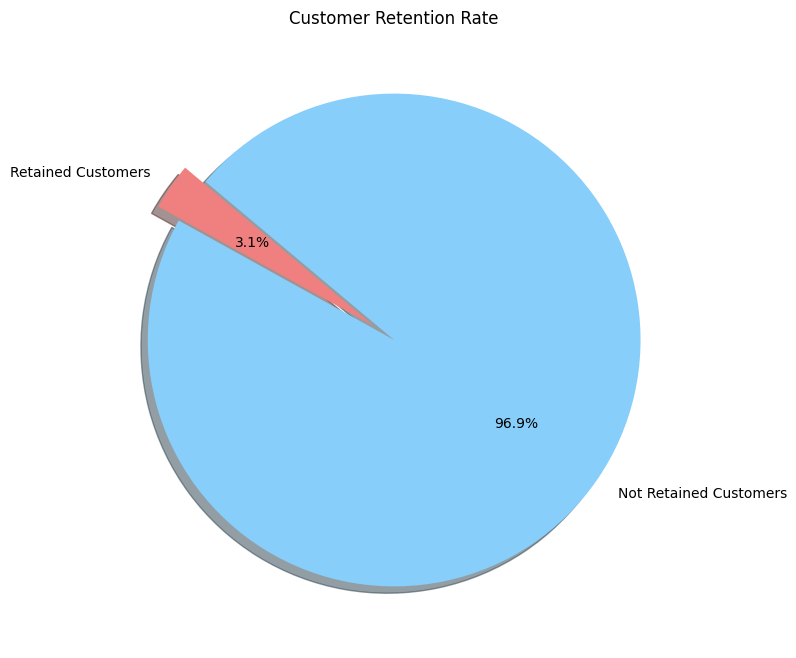

In [43]:
#Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase
customer_order_counts = merge.groupby('customer_unique_id')['order_id'].nunique()
repeat_customers = (customer_order_counts > 1).sum()
total_customers = customer_order_counts.count()
retention_rate = (repeat_customers / total_customers) * 100

print(f"Retentation rate:{retention_rate:.2f}%")

labels = ['Retained Customers', 'Not Retained Customers']
plt.figure(figsize=(8, 8))
plt.pie([repeat_customers, total_customers-repeat_customers],explode = (0.1, 0), labels=labels, colors = ['lightcoral', 'lightskyblue'], autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Customer Retention Rate')
plt.show()

                     customer_unique_id    price
3799   0a0a92112bd4c708ca5fde585afaa872  13440.0
81388  da122df9eeddfedc1dc1f5349a1a690c   7388.0
44139  763c8b1c9c68a0229c42c9fc6f662b93   7160.0


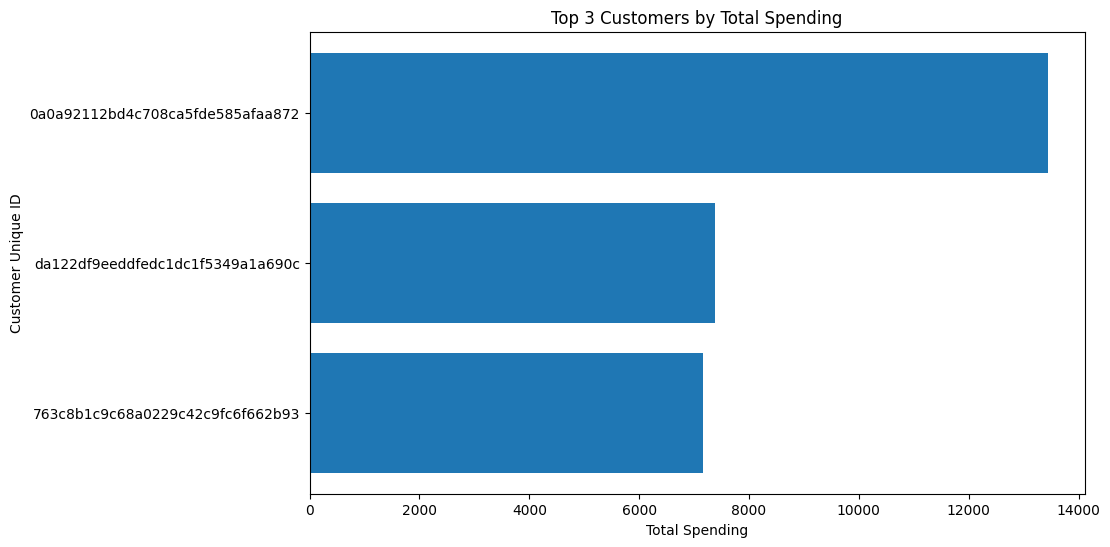

In [49]:
# Identify the top 3 customers who spent the most money in each year.
top_customers = merge.groupby('customer_unique_id')['price'].sum().reset_index()
Top_3_customers = top_customers.sort_values(by='price', ascending=False).head(3)
print(Top_3_customers)
plt.figure(figsize=(10, 6))
plt.barh(Top_3_customers['customer_unique_id'], Top_3_customers['price'])
plt.title('Top 3 Customers by Total Spending')
plt.ylabel('Customer Unique ID')
plt.xlabel('Total Spending')
plt.gca().invert_yaxis()
plt.show()